In [3]:
"""
Makine Öğrenmesi Final Ödevi
Türkiye Yapay Zeka Akademisi

Proje Amacı:
Bu projede Breast Cancer Wisconsin veri seti kullanılarak
iyi huylu ve kötü huylu tümörlerin sınıflandırılması amaçlanmaktadır.

Projede veri inceleme, eksik değer kontrolü, aykırı değer analizi,
öznitelik mühendisliği, kategorik değişkenlerin kodlanması,
ölçekleme, öznitelik seçimi, train-validation-test ayrımı,
model karşılaştırması, çapraz doğrulama, hiperparametre optimizasyonu
ve final test değerlendirmesi uygulanmaktadır.

Kullanılan Kütüphaneler:
pandas, numpy, matplotlib, seaborn ve scikit-learn

Çalıştırma:
Notebook hücreleri yukarıdan aşağıya doğru sırasıyla çalıştırılmalıdır.
"""

print("Makine Öğrenmesi Final Projesi başlatıldı.")

Makine Öğrenmesi Final Projesi başlatıldı.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [5]:
cancer = load_breast_cancer(as_frame=True)

df = cancer.frame.copy()

print("Veri seti başarıyla yüklendi.")
print("Veri seti boyutu:", df.shape)

display(df.head())

Veri seti başarıyla yüklendi.
Veri seti boyutu: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print("""
PROBLEM TANIMI

Bu projede Breast Cancer Wisconsin veri seti kullanılmıştır.

Amaç, tümörlere ait ölçümlerden yararlanarak bir tümörün
iyi huylu (benign) veya kötü huylu (malignant) olduğunu
tahmin etmektir.

Hedef değişken: target

target = 0 -> Kötü huylu (Malignant)
target = 1 -> İyi huylu (Benign)

Hedef değişken iki sınıftan oluştuğu için bu problem
bir SINIFLANDIRMA problemidir.
""")


PROBLEM TANIMI

Bu projede Breast Cancer Wisconsin veri seti kullanılmıştır.

Amaç, tümörlere ait ölçümlerden yararlanarak bir tümörün
iyi huylu (benign) veya kötü huylu (malignant) olduğunu
tahmin etmektir.

Hedef değişken: target

target = 0 -> Kötü huylu (Malignant)
target = 1 -> İyi huylu (Benign)

Hedef değişken iki sınıftan oluştuğu için bu problem
bir SINIFLANDIRMA problemidir.



In [7]:
print("İlk 5 satır:")
display(df.head())

print("\nSatır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

İlk 5 satır:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Satır sayısı: 569
Sütun sayısı: 31


In [8]:
print("Veri seti bilgileri:")
df.info()

Veri seti bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

In [9]:
print("Temel istatistikler:")
display(df.describe().T)

Temel istatistikler:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [10]:
target_counts = df["target"].value_counts().sort_index()

target_table = pd.DataFrame({
    "Sınıf": ["Malignant (0)", "Benign (1)"],
    "Gözlem Sayısı": [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
})

display(target_table)

print("\nOransal dağılım:")
print(df["target"].value_counts(normalize=True).sort_index().round(3))

,Sınıf,Gözlem Sayısı
0,Malignant (0),212
1,Benign (1),357



Oransal dağılım:
target
0    0.373
1    0.627
Name: proportion, dtype: float64


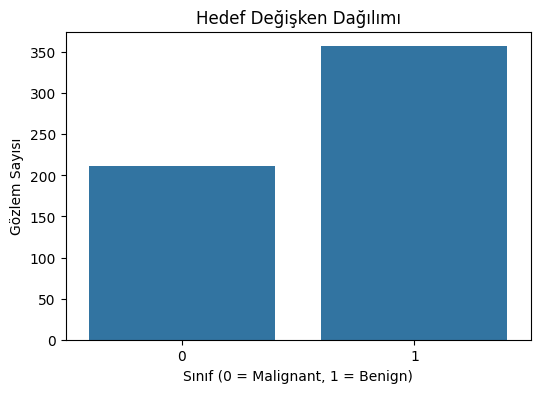

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Hedef Değişken Dağılımı")
plt.xlabel("Sınıf (0 = Malignant, 1 = Benign)")
plt.ylabel("Gözlem Sayısı")

plt.show()

In [12]:
missing_values = pd.DataFrame({
    "Eksik Değer Sayısı": df.isnull().sum(),
    "Eksik Değer Oranı (%)": (df.isnull().mean() * 100).round(2)
})

print("Toplam eksik değer sayısı:", df.isnull().sum().sum())

display(
    missing_values[
        missing_values["Eksik Değer Sayısı"] > 0
    ]
)

Toplam eksik değer sayısı: 0


,Eksik Değer Sayısı,Eksik Değer Oranı (%)


In [13]:
print("""
EKSİK DEĞER YORUMU

Veri setindeki eksik değerler kontrol edilmiştir.

Veri setinde eksik değer bulunmadığı için herhangi bir gözlem
silme veya değer doldurma işlemi yapılmasına gerek kalmamıştır.

Bununla birlikte modelleme pipeline'ında sayısal değişkenler için
medyan, kategorik değişkenler için en sık görülen değer ile
doldurma adımı tanımlanacaktır. Böylece pipeline olası eksik
değerlere karşı dayanıklı hale getirilecektir.
""")


EKSİK DEĞER YORUMU

Veri setindeki eksik değerler kontrol edilmiştir.

Veri setinde eksik değer bulunmadığı için herhangi bir gözlem
silme veya değer doldurma işlemi yapılmasına gerek kalmamıştır.

Bununla birlikte modelleme pipeline'ında sayısal değişkenler için
medyan, kategorik değişkenler için en sık görülen değer ile
doldurma adımı tanımlanacaktır. Böylece pipeline olası eksik
değerlere karşı dayanıklı hale getirilecektir.



In [14]:
numeric_columns = df.drop(columns="target").select_dtypes(
    include=np.number
).columns

outlier_results = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()

    outlier_results.append({
        "Değişken": column,
        "Aykırı Değer Sayısı": count
    })

outlier_df = pd.DataFrame(outlier_results)

display(
    outlier_df.sort_values(
        "Aykırı Değer Sayısı",
        ascending=False
    ).head(10)
)

,Değişken,Aykırı Değer Sayısı
13,area error,65
10,radius error,38
12,perimeter error,38
23,worst area,35
14,smoothness error,30
19,fractal dimension error,28
15,compactness error,28
18,symmetry error,27
3,mean area,25
29,worst fractal dimension,24


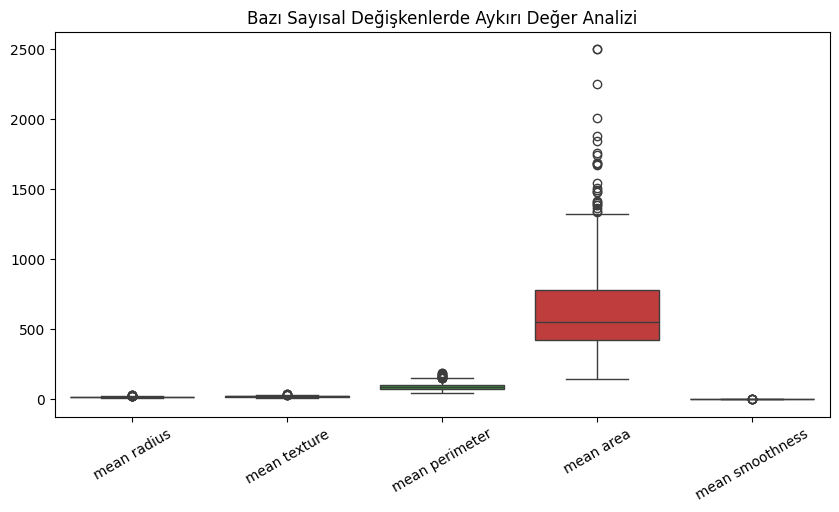

In [15]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[
        [
            "mean radius",
            "mean texture",
            "mean perimeter",
            "mean area",
            "mean smoothness"
        ]
    ]
)

plt.title("Bazı Sayısal Değişkenlerde Aykırı Değer Analizi")
plt.xticks(rotation=30)

plt.show()

In [16]:
print("""
AYKIRI DEĞER YORUMU

Sayısal değişkenlerde IQR yöntemi kullanılarak aykırı değerler
incelenmiştir.

Bazı değişkenlerde aykırı gözlemler bulunmaktadır. Ancak bu
değerler gerçek tıbbi ölçümleri temsil edebileceğinden doğrudan
silinmemiştir.

Özellikle sağlık verilerinde uç değerler önemli klinik bilgiler
içerebileceği için gözlemleri koruma yaklaşımı tercih edilmiştir.
Modelleme sırasında sayısal değişkenlere StandardScaler
uygulanacaktır.
""")


AYKIRI DEĞER YORUMU

Sayısal değişkenlerde IQR yöntemi kullanılarak aykırı değerler
incelenmiştir.

Bazı değişkenlerde aykırı gözlemler bulunmaktadır. Ancak bu
değerler gerçek tıbbi ölçümleri temsil edebileceğinden doğrudan
silinmemiştir.

Özellikle sağlık verilerinde uç değerler önemli klinik bilgiler
içerebileceği için gözlemleri koruma yaklaşımı tercih edilmiştir.
Modelleme sırasında sayısal değişkenlere StandardScaler
uygulanacaktır.



In [17]:
df["area_per_radius"] = (
    df["mean area"] /
    (df["mean radius"] + 1e-6)
)

df["perimeter_radius_ratio"] = (
    df["mean perimeter"] /
    (df["mean radius"] + 1e-6)
)

print("Yeni oluşturulan özellikler:")
print("1. area_per_radius")
print("2. perimeter_radius_ratio")

display(
    df[
        [
            "mean radius",
            "mean area",
            "mean perimeter",
            "area_per_radius",
            "perimeter_radius_ratio"
        ]
    ].head()
)

Yeni oluşturulan özellikler:
1. area_per_radius
2. perimeter_radius_ratio


,mean radius,mean area,mean perimeter,area_per_radius,perimeter_radius_ratio
0,17.99,1001.0,122.80,55.642020,6.826014
1,20.57,1326.0,132.90,64.462807,6.460865
2,19.69,1203.0,130.00,61.097000,6.602336
3,11.42,386.1,77.58,33.809104,6.793344
4,20.29,1297.0,135.10,63.923112,6.658452


In [18]:
df["radius_group"] = pd.cut(
    df["mean radius"],
    bins=[-np.inf, 12, 16, np.inf],
    labels=["Kucuk", "Orta", "Buyuk"]
)

print("Radius Group dağılımı:")
display(df["radius_group"].value_counts())

Radius Group dağılımı:


,count
radius_group,
Orta,257
Kucuk,171
Buyuk,141


In [19]:
print("""
ÖZNİTELİK MÜHENDİSLİĞİ

Projede üç yeni değişken oluşturulmuştur:

1. area_per_radius:
   Ortalama tümör alanının ortalama yarıçapa oranını gösterir.

2. perimeter_radius_ratio:
   Ortalama çevrenin ortalama yarıçapa oranını gösterir.

3. radius_group:
   Ortalama yarıçap değerini küçük, orta ve büyük olmak üzere
   üç kategoride ifade eder.

Bu özelliklerin tümörün geometrik özelliklerini farklı şekillerde
temsil ederek modele ek bilgi sağlaması amaçlanmıştır.
""")


ÖZNİTELİK MÜHENDİSLİĞİ

Projede üç yeni değişken oluşturulmuştur:

1. area_per_radius:
   Ortalama tümör alanının ortalama yarıçapa oranını gösterir.

2. perimeter_radius_ratio:
   Ortalama çevrenin ortalama yarıçapa oranını gösterir.

3. radius_group:
   Ortalama yarıçap değerini küçük, orta ve büyük olmak üzere
   üç kategoride ifade eder.

Bu özelliklerin tümörün geometrik özelliklerini farklı şekillerde
temsil ederek modele ek bilgi sağlaması amaçlanmıştır.



In [20]:
X = df.drop(columns=["target"])
y = df["target"]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (569, 33)
y boyutu: (569,)


In [21]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nYaklaşık dağılım:")
print("%60 Train")
print("%20 Validation")
print("%20 Test")

Train: (341, 33)
Validation: (114, 33)
Test: (114, 33)

Yaklaşık dağılım:
%60 Train
%20 Validation
%20 Test


In [22]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Sayısal değişken sayısı:", len(numeric_features))
print("Kategorik değişkenler:", categorical_features)

Sayısal değişken sayısı: 32
Kategorik değişkenler: ['radius_group']


In [23]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Ön işleme pipeline'ı oluşturuldu.")
print("- Eksik değer işlemleri")
print("- StandardScaler")
print("- One-Hot Encoding")

Ön işleme pipeline'ı oluşturuldu.
- Eksik değer işlemleri
- StandardScaler
- One-Hot Encoding


In [24]:
feature_selector = SelectKBest(
    score_func=f_classif,
    k=15
)

print("Öznitelik seçim yöntemi:")
print("SelectKBest + ANOVA F-Test")
print("En yüksek skora sahip 15 özellik seçilecektir.")

Öznitelik seçim yöntemi:
SelectKBest + ANOVA F-Test
En yüksek skora sahip 15 özellik seçilecektir.


In [25]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

print("Karşılaştırılacak modeller:")

for model_name in models:
    print("-", model_name)

Karşılaştırılacak modeller:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest


In [26]:
model_pipelines = {}

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("feature_selection", feature_selector),
            ("model", model)
        ]
    )

    model_pipelines[model_name] = pipeline

print("Model pipeline'ları hazır.")

Model pipeline'ları hazır.


In [27]:
validation_results = []

for model_name, pipeline in model_pipelines.items():

    pipeline.fit(X_train, y_train)

    y_val_pred = pipeline.predict(X_val)

    validation_results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_val,
            y_val_pred
        ),

        "Precision": precision_score(
            y_val,
            y_val_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            y_val_pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_val,
            y_val_pred,
            zero_division=0
        )
    })

validation_df = pd.DataFrame(validation_results)

validation_df = validation_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    validation_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.939,0.944,0.958,0.951
1,Decision Tree,0.939,0.944,0.958,0.951
2,Random Forest,0.939,0.944,0.958,0.951
3,KNN,0.921,0.931,0.944,0.937


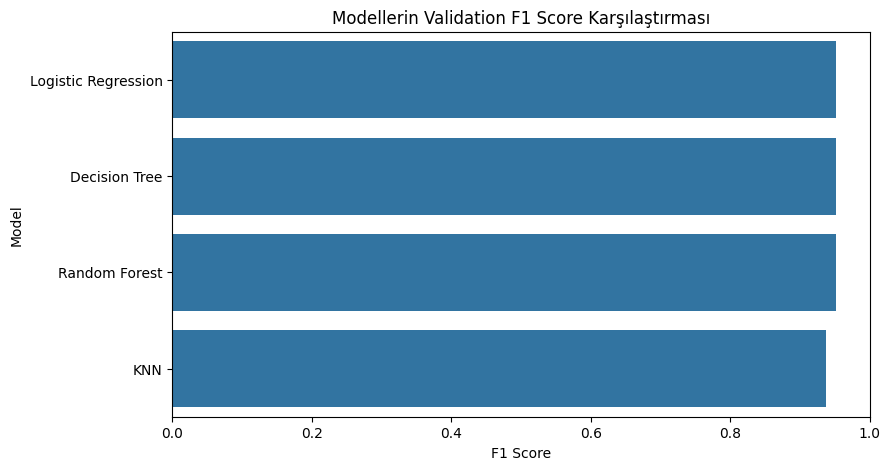

In [28]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=validation_df,
    x="F1 Score",
    y="Model"
)

plt.title("Modellerin Validation F1 Score Karşılaştırması")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()

In [29]:
best_model_name = validation_df.iloc[0]["Model"]

best_pipeline = model_pipelines[best_model_name]

print(
    "Validation F1 Score sonucuna göre en başarılı model:",
    best_model_name
)

Validation F1 Score sonucuna göre en başarılı model: Logistic Regression


In [30]:
cv_scores = cross_val_score(
    best_pipeline,
    X_train_val,
    y_train_val,
    cv=5,
    scoring="f1"
)

print("5-Fold Cross Validation F1 skorları:")
print(np.round(cv_scores, 3))

print(
    "\nOrtalama F1:",
    round(cv_scores.mean(), 3)
)

print(
    "Standart Sapma:",
    round(cv_scores.std(), 3)
)

5-Fold Cross Validation F1 skorları:
[0.974 0.973 0.94  0.938 0.965]

Ortalama F1: 0.958
Standart Sapma: 0.016


In [31]:
if best_model_name == "Random Forest":

    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5]
    }

elif best_model_name == "Decision Tree":

    param_grid = {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }

elif best_model_name == "KNN":

    param_grid = {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    }

else:

    param_grid = {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "lbfgs"]
    }

print("GridSearchCV parametreleri:")
print(param_grid)

GridSearchCV parametreleri:
{'model__C': [0.01, 0.1, 1, 10, 100], 'model__solver': ['liblinear', 'lbfgs']}


In [32]:
grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train_val,
    y_train_val
)

print("En iyi parametreler:")
print(grid_search.best_params_)

print(
    "\nEn iyi Cross Validation F1:",
    round(grid_search.best_score_, 3)
)

En iyi parametreler:
{'model__C': 100, 'model__solver': 'liblinear'}

En iyi Cross Validation F1: 0.962


In [33]:
final_model = grid_search.best_estimator_

print("Final model:", best_model_name)
print("Model GridSearchCV sonucunda optimize edildi.")

Final model: Logistic Regression
Model GridSearchCV sonucunda optimize edildi.


In [34]:
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print("FINAL TEST SONUÇLARI")
print("-" * 35)

print(f"Accuracy  : {test_accuracy:.3f}")
print(f"Precision : {test_precision:.3f}")
print(f"Recall    : {test_recall:.3f}")
print(f"F1 Score  : {test_f1:.3f}")

FINAL TEST SONUÇLARI
-----------------------------------
Accuracy  : 0.974
Precision : 0.986
Recall    : 0.972
F1 Score  : 0.979


In [35]:
print("CLASSIFICATION REPORT")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



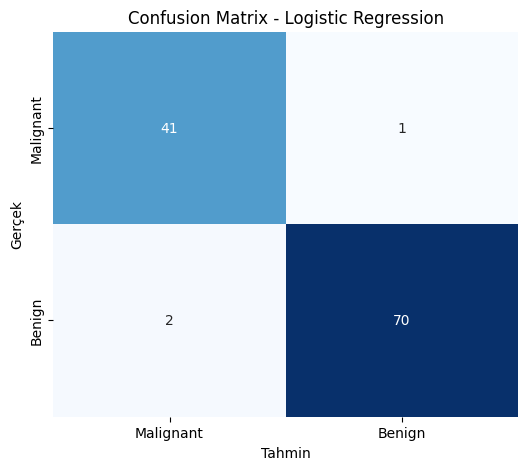

In [36]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Malignant",
        "Benign"
    ],
    yticklabels=[
        "Malignant",
        "Benign"
    ]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")

plt.show()

In [37]:
permutation_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_result.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("En önemli 10 değişken:")

display(importance_df.head(10))

En önemli 10 değişken:


,Feature,Importance
0,worst area,0.342906
1,area_per_radius,0.273437
2,mean concave points,0.183104
3,worst radius,0.136461
4,mean radius,0.060959
5,mean compactness,0.053877
6,worst compactness,0.050625
7,perimeter_radius_ratio,0.050220
8,worst perimeter,0.047254
9,mean perimeter,0.034335


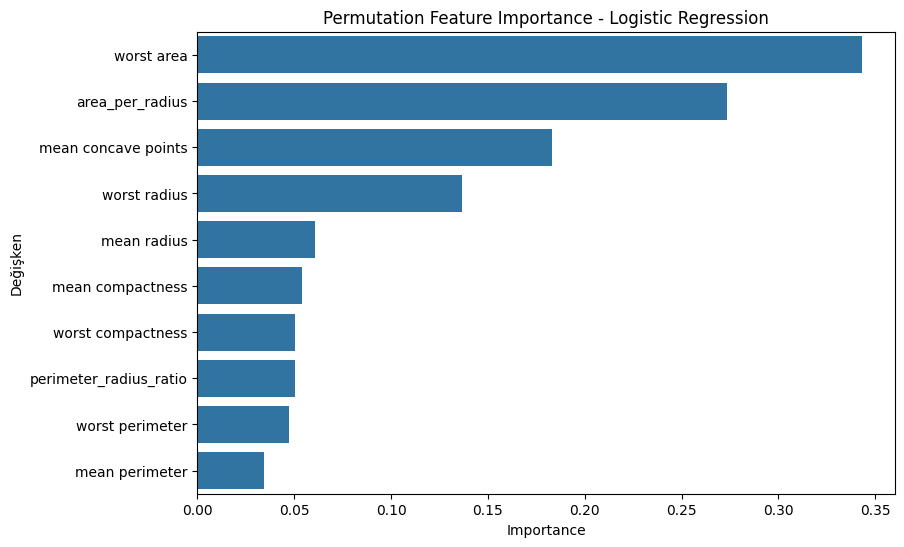

In [38]:
top_features = importance_df.head(10)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    f"Permutation Feature Importance - {best_model_name}"
)

plt.xlabel("Importance")
plt.ylabel("Değişken")

plt.show()

In [39]:
top_3_features = (
    importance_df
    .head(3)["Feature"]
    .tolist()
)

print(f"""
SONUÇ DEĞERLENDİRMESİ

Bu projede Logistic Regression, KNN, Decision Tree ve
Random Forest modelleri karşılaştırılmıştır.

Validation F1 Score sonuçlarına göre en başarılı model
{best_model_name} olmuştur.

Seçilen model üzerinde 5 katlı çapraz doğrulama uygulanmış
ve GridSearchCV kullanılarak hiperparametre optimizasyonu
gerçekleştirilmiştir.

Final modelin test sonuçları:

Accuracy  : {test_accuracy:.3f}
Precision : {test_precision:.3f}
Recall    : {test_recall:.3f}
F1 Score  : {test_f1:.3f}

Permutation Importance analizine göre model tahminlerinde
öne çıkan üç değişken:

1. {top_3_features[0]}
2. {top_3_features[1]}
3. {top_3_features[2]}

Sonuçlar modelin iyi huylu ve kötü huylu tümörleri ayırt etmede
başarılı olduğunu göstermektedir.

Bununla birlikte veri setinin yalnızca 569 gözlem içermesi ve
belirli tümör özellikleriyle sınırlı olması projenin önemli
sınırlılıklarıdır. Daha büyük ve farklı hasta gruplarından elde
edilen veri setleriyle modelin genellenebilirliği ayrıca
değerlendirilebilir.
""")


SONUÇ DEĞERLENDİRMESİ

Bu projede Logistic Regression, KNN, Decision Tree ve
Random Forest modelleri karşılaştırılmıştır.

Validation F1 Score sonuçlarına göre en başarılı model
Logistic Regression olmuştur.

Seçilen model üzerinde 5 katlı çapraz doğrulama uygulanmış
ve GridSearchCV kullanılarak hiperparametre optimizasyonu
gerçekleştirilmiştir.

Final modelin test sonuçları:

Accuracy  : 0.974
Precision : 0.986
Recall    : 0.972
F1 Score  : 0.979

Permutation Importance analizine göre model tahminlerinde
öne çıkan üç değişken:

1. worst area
2. area_per_radius
3. mean concave points

Sonuçlar modelin iyi huylu ve kötü huylu tümörleri ayırt etmede
başarılı olduğunu göstermektedir.

Bununla birlikte veri setinin yalnızca 569 gözlem içermesi ve
belirli tümör özellikleriyle sınırlı olması projenin önemli
sınırlılıklarıdır. Daha büyük ve farklı hasta gruplarından elde
edilen veri setleriyle modelin genellenebilirliği ayrıca
değerlendirilebilir.



In [40]:
fitted_preprocessor = final_model.named_steps["preprocessor"]

all_feature_names = fitted_preprocessor.get_feature_names_out()

selector = final_model.named_steps["feature_selection"]

selected_mask = selector.get_support()

selected_features = all_feature_names[selected_mask]

feature_scores = selector.scores_[selected_mask]

selected_feature_df = pd.DataFrame({
    "Seçilen Özellik": selected_features,
    "ANOVA F Score": feature_scores
}).sort_values(
    "ANOVA F Score",
    ascending=False
)

print("SelectKBest ile seçilen 15 özellik:")

display(selected_feature_df)

SelectKBest ile seçilen 15 özellik:


,Seçilen Özellik,ANOVA F Score
11,num__worst concave points,795.223341
7,num__worst perimeter,719.598823
5,num__mean concave points,703.364031
6,num__worst radius,687.430367
1,num__mean perimeter,565.485755
8,num__worst area,541.713694
12,num__area_per_radius,531.410062
0,num__mean radius,523.613907
2,num__mean area,469.516453
14,cat__radius_group_Buyuk,433.484731


In [41]:
kontrol = pd.DataFrame({
    "Ödev Maddesi": [
        "1. Docstring",
        "2. Veri seti",
        "3. Hedef ve problem türü",
        "4. Temel veri inceleme",
        "5. Eksik değer kontrolü",
        "6. Kategorik encoding",
        "7. Aykırı değer analizi",
        "8. Scaling",
        "9. Feature Engineering",
        "10. Feature Selection",
        "11. Train / Validation / Test",
        "12. En az 3 model",
        "13. Validation karşılaştırması",
        "14. Hyperparameter tuning",
        "15. Final test metrikleri",
        "16. Sonuç yorumu",
        "17. Açıklanabilirlik (Bonus)"
    ],

    "Durum": ["Tamam"] * 17
})

display(kontrol)

,Ödev Maddesi,Durum
0,1. Docstring,Tamam
1,2. Veri seti,Tamam
2,3. Hedef ve problem türü,Tamam
3,4. Temel veri inceleme,Tamam
4,5. Eksik değer kontrolü,Tamam
5,6. Kategorik encoding,Tamam
6,7. Aykırı değer analizi,Tamam
7,8. Scaling,Tamam
8,9. Feature Engineering,Tamam
9,10. Feature Selection,Tamam
